### Construct ti-ureate complexes
In this tutorial, we will use the $\texttt{TM catalyst framework}$ package to generate all the different isomers of a ti-ureate complex.
First we need to import the $\texttt{Complex}$ from the package.
This would be the main function we will use to create the complex.

In [1]:
# import TM_catalyst_framework.metal_template as template
# import the package
import os # package for reading, creating and saving files or directories
from TM_catalyst_framework import Template, Complex, Ligand, GeoOpt, QChem

Template().options()

tetrahedral
octahedral
trigonal_planar
square_pyramidal
trigonal_bipyramidal


![alt text](figure/figure1.png)

In the first example, we will be constructing a ti-bisureate complex with bidentate ureate ligands.
The complex has six coordination sites, forming an octahedral geometry, with dimethylamido ligands binding to the metal center in the remaining two coordination sites.
To generate the 3D structure of the stereoisomer, you need to:
- Define the geometry of the complex, so the code can load the geometry template internally
- Provide the SMILE stirngs of the ligand(s) that will coordinate the metal center, where for each ligand:
    - Use "*" in the SMILES string to indicate where the ligand would bind to the metal center
    - For bidentate ligands, define which atom is binding to which coordination site



In [22]:
# --------------------------------------------------------------
# Define geometry
# --------------------------------------------------------------
geometry = "octahedral" 

In [23]:
# --------------------------------------------------------------
# Define ligand
# bidentate ligand where nitrogen attaching Ti has two substituents
# --------------------------------------------------------------
from TM_catalyst_framework.complex import Mapping

metal_ligand_coord_map = Mapping({})
precursor_ligand = "*N(C)C"
metal_ligand_coord_map.add_monodentate(ligand_SMILES=precursor_ligand,
                                       coordination_site=1)
metal_ligand_coord_map.add_monodentate(ligand_SMILES=precursor_ligand,
                                       coordination_site=6)


<>:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
/var/folders/4g/_4b7gwg52572r3yvvt5619t80000gn/T/ipykernel_31526/557403016.py:2: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  ureate_ligand1_SMILES = "CC(C)c1cccc(C(C)C)c1/N=C(\O[*:1])[N@@+](C)([C@H](C)c1ccccc1)[*:2]"


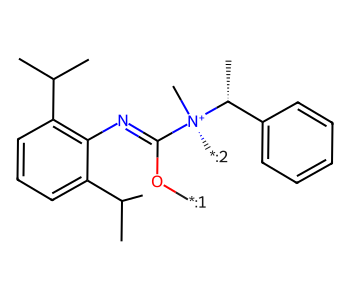

In [ ]:
# Ureate ligand SMILES
ureate_ligand1_SMILES = "CC(C)c1cccc(C(C)C)c1/N=C(\O[*:1])[N@@+](C)([C@H](C)c1ccccc1)[*:2]"

# You can draw the ligand out
# especially for ligand with higher denticity
# so that you can check the order of the donor atoms
Ligand(ureate_ligand1_SMILES).draw_ligand()

In [26]:
# In thie case the nitrogen is the going to attach to coordination site 1
# and the oxygen is going to attach to site 2 on the metal template

metal_ligand_coord_map.add_bidentate(ligand_SMILES=ureate_ligand1_SMILES, #The SMILES of the ureate ligand with dummies "*"
                                     coordination_site_1= 2, #Define the first atom on the ligand that is coordinating to Ti, and which coordination site
                                     coordination_site_2= 3#Define the second atom on the ligand that is coordinating to Ti, and which coordination site
                                     )
ureate_ligand2_SMILES = ureate_ligand1_SMILES#"CC(C1=CC=CC=C1)N(/C([N+](C2=C(C=CC=C2C(C)C)C(C)C)[*:1])O\[*:2])C"
#"CC(C1=CC=CC=C1)N(/C(N(C2=C(C=CC=C2C(C)C)C(C)C)[*:2])=O\[*:1])C"
metal_ligand_coord_map.add_bidentate(ligand_SMILES=ureate_ligand2_SMILES, #The SMILES of the ureate ligand with dummies "*"
                                     coordination_site_1= 4, #Define the first atom on the ligand that is coordinating to Ti, and which coordination site
                                     coordination_site_2= 5#Define the second atom on the ligand that is coordinating to Ti, and which coordination site
                                     )

In [27]:
print (metal_ligand_coord_map.attach_scheme)

{1: ['*N(C)C', 1], 2: ['*N(C)C', 6], 3: ['CC(C)c1cccc(C(C)C)c1/N=C(\\O[*:1])[N@@+](C)([C@H](C)c1ccccc1)[*:2]', [2, 3]], 4: ['CC(C)c1cccc(C(C)C)c1/N=C(\\O[*:1])[N@@+](C)([C@H](C)c1ccccc1)[*:2]', [4, 5]]}


In [28]:

ff_energy = 8001 # initialize ff_energy variable
while ff_energy > 8000: # set a threshold for ff_energy to generate complex
    # --------------------------------------------------------------
    # Define output directory and filename
    # --------------------------------------------------------------
    output_save_dir = "./geometry_output_sdf/" # define the directory where the output file will be saved.
    if os.path.isdir(output_save_dir) != True: # check if the directory exists
        os.mkdir(output_save_dir)               # create directory if it doesn't exist
    output_filename = output_save_dir+f"u2_d2d2_iso1_product_N2"     #Define the output file name, which will be saved as .sdf format
    output_format = "sdf" # define output format, options: "sdf", "xyz". Default: "sdf"

    # initialize the complex by defining the metal center identity
    create_complex = Complex(metal_center="Ti", # must
                            force_field = "uff", # default: uff, options: ghemical, uff, mmff94
                            force_field_steps = 4000 # optional
                            )

    # Create the geometry
    create_complex.generate_complex(geometry = geometry,
                                        output_filename=output_filename,
                                        output_format= output_format,
                                        attach_scheme= metal_ligand_coord_map.attach_scheme,
                                        )
    ff_energy = create_complex.ff_energy
    print (f"Final FF energy is {ff_energy} kcal/mol")


True
Molecule with 7 atoms
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...


[12:54:21] UFFTYPER: Unrecognized atom type: *_ (0)
[12:54:21] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[12:54:22] UFFTYPER: Unrecognized atom type: *_ (0)
[12:54:22] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[12:54:22] UFFTYPER: Unrecognized atom type: *_ (15)
[12:54:22] UFFTYPER: Unrecognized atom type: *_ (26)
[12:54:22] UFFTYPER: Unrecognized atom type: *_ (15)
[12:54:22] UFFTYPER: Unrecognized atom type: *_ (26)


Final ligand energy: 61.97 kcal/mol
Running constrained optimization...


*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



*
*
*
*
*
*
*
Running constrained optimization...


...

*
*
*
*
*
*
*
Running constrained optimization...


[12:55:04] UFFTYPER: Unrecognized atom type: *_ (15)
[12:55:04] UFFTYPER: Unrecognized atom type: *_ (26)
[12:55:04] UFFTYPER: Unrecognized atom type: *_ (15)
[12:55:04] UFFTYPER: Unrecognized atom type: *_ (26)


Final ligand energy: 63.38 kcal/mol
Running constrained optimization...


*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



*
*
*
*
*
*
*
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...
Final FF energy is 5064.539974160621 kcal/mol


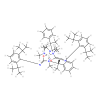

In [10]:
# you can see the 2D projection of the complex by calling .complex:
complex_mol = create_complex.complex
complex_mol

In [11]:
create_complex.ff_energy

5172.178332327868

In [12]:
complex_mol.write("xyz", f"{output_filename}.xyz", overwrite=True)

In [13]:
# Alternatively, you can also use the mol_visual module to view the 3D strucutre of the sdf file 
from TM_catalyst_framework.io_utils import mol_visual
mol_3d = mol_visual.visualize_sdf_molecule(output_filename+".sdf")
mol_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

![alt text](figure/figure2.png)

In [14]:
# --------------------------------------------------------------
# Generate QChem input file
# --------------------------------------------------------------

import TM_catalyst_framework.QChem as qchem

ORCA_save_dir = "./ORCA_calc/" # define the directory where the output file will be saved.
if os.path.isdir(ORCA_save_dir) != True: # check if the directory exists
    os.mkdir(ORCA_save_dir)               # create directory if it doesn't exist
ORCA_filename = ORCA_save_dir+f"u2_d2d2_iso1_product_N2"  

qchem_util = qchem(software="ORCA")  # Currently only QChem is supported

input_util = qchem_util.generate_input(method = "DFT",
                                            mol = create_complex.complex, # molecule object
                        basis_set = "def2-SVP", # basis set
                        task = "opt", # geometry optimization
                        functional = "B3LYP", # DFT functional
                        filename = ORCA_filename + ".inp", # ORCA calculation input filename
)


[('Ti', 0.48402, -0.52559, -0.64242), ('N', 0.68209, -1.0981, 1.43189), ('C', 1.6847, -0.53318, 2.35862), ('C', -0.54261, -1.5428, 2.13895), ('H', 2.63897, -0.33576, 1.8328), ('H', 1.87748, -1.2156, 3.20329), ('H', 1.32124, 0.32941, 2.93089), ('H', -1.16804, -2.17286, 1.48302), ('H', -1.18371, -0.71733, 2.49202), ('H', -0.28053, -2.1611, 3.02291), ('N', 0.32882, 0.0327, -2.71557), ('C', -0.92713, 0.42978, -3.38869), ('C', 1.48462, 0.77768, -3.26526), ('H', -0.96137, 1.4886, -3.71048), ('H', -1.82372, 0.09712, -2.84467), ('H', -0.94751, 0.01526, -4.39042), ('H', 2.43034, 0.21347, -3.16095), ('H', 1.37918, 0.94964, -4.35596), ('H', 1.60167, 1.76098, -2.77423), ('C', 4.59902, -5.94768, -3.91228), ('C', 3.5059, -5.73973, -2.86019), ('C', 3.37667, -7.04933, -2.02565), ('C', 2.22287, -5.32968, -3.57709), ('C', 1.54789, -6.36215, -4.26901), ('C', 0.41783, -6.12736, -5.01171), ('C', -0.03829, -4.84789, -5.16737), ('C', 0.60283, -3.75196, -4.55105), ('C', 0.11758, -2.36362, -4.93228), ('C', -1.

True
Molecule with 7 atoms
Replace Ti with {self.metal_center}.
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...


[12:49:47] UFFTYPER: Unrecognized atom type: *_ (0)
[12:49:47] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[12:49:47] UFFTYPER: Unrecognized atom type: *_ (0)
[12:49:47] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[12:49:47] UFFTYPER: Unrecognized atom type: *_ (15)
[12:49:47] UFFTYPER: Unrecognized atom type: *_ (26)
[12:49:47] UFFTYPER: Unrecognized atom type: *_ (15)
[12:49:47] UFFTYPER: Unrecognized atom type: *_ (26)


Final ligand energy: 55.05 kcal/mol
Running constrained optimization...
*
*
*
*
*
*
*
Running constrained optimization...


*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[12:49:49] UFFTYPER: Unrecognized atom type: *_ (15)
[12:49:49] UFFTYPER: Unrecognized atom type: *_ (26)
[12:49:49] UFFTYPER: Unrecognized atom type: *_ (15)
[12:49:49] UFFTYPER: Unrecognized atom type: *_ (26)


Final ligand energy: 58.22 kcal/mol
Running constrained optimization...


*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



*
*
*
*
*
*
*
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...


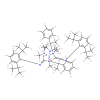

In [15]:

# --------------------------------------------------------------
# One has the flexibility to change the metal center
# e.g. if we swap Ti to Ta; note, the default metal_center = "Ti"
# Define output directory and filename
# --------------------------------------------------------------
metal_center = "Ta"
output_format = "xyz"
output_save_dir = f"./{metal_center}_geometry_output_xyz/" # define the directory where the output file will be saved.
if os.path.isdir(output_save_dir) != True: # check if the directory exists
    os.mkdir(output_save_dir)               # create directory if it doesn't exist
output_sdf = output_save_dir+f"u2_d2d2_iso1_product_N2"     #Define the output file name, which will be saved as .sdf format


# initialize the complex by defining the metal center identity
create_complex = Complex(metal_center=metal_center, # must
                         force_field = "uff", # default: uff, options: ghemical, uff, mmff94
                         force_field_steps = 5000 # optional
                         )

# Create the geometry
create_complex.generate_complex(geometry,
                                output_filename=output_sdf,
                                output_format= output_format,
                                attach_scheme= metal_ligand_coord_map.attach_scheme,
                                       )
# you can see the 2D projection of the complex by calling .complex:
create_complex.complex

True
Molecule with 7 atoms
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...


[12:50:02] UFFTYPER: Unrecognized atom type: *_ (0)
[12:50:02] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



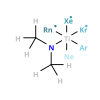

In [16]:
import importlib
from TM_catalyst_framework import Complex
# In case you want to load the template separately
from TM_catalyst_framework.metal_template import Template

template_util = Template(package = "openbabel") # this is the default

template = template_util.load_ti_template_sdf(f"{geometry}.sdf")
create_complex = Complex(metal_center=template_util.metal_center, 
                         force_field = "uff",
                        force_field_steps = 10000
                         )

# you can just add monodentate ligand yourself
mol2 = create_complex.attach_monodentate_ligand(template,
                                         precursor_ligand,
                                         coord_site=1, 
                                         halogen_mapping = True
                                         )
mol2

In [17]:
mol2_3d = mol_visual.visualize_mol_molecule(mol2)
mol2_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object


[12:50:11] UFFTYPER: Unrecognized atom type: *_ (15)
[12:50:11] UFFTYPER: Unrecognized atom type: *_ (26)
[12:50:11] UFFTYPER: Unrecognized atom type: *_ (15)
[12:50:11] UFFTYPER: Unrecognized atom type: *_ (26)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



Final ligand energy: 60.71 kcal/mol
Running constrained optimization...
*
*
*
*
*
*
*
Running constrained optimization...


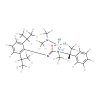

In [18]:
# you can just add monodentate ligand yourself
create_complex.attach_bidentate_ligand(mol2,
                                         ligand_smiles = ureate_ligand1_SMILES,
                                         coordination_info = [2, 3]
                                         )
create_complex.complex

In [19]:
mol2_3d = mol_visual.visualize_mol_molecule(mol2)
mol2_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object


In [20]:
from TM_catalyst_framework.GeoOpt import GeoOpt

GeoOpt_util = GeoOpt(force_field = "uff",
                             force_field_steps = 5000,
                             metal_center = "Ti")
mol2_opt, constraints = GeoOpt_util.constraint_metal_opt(mol2)

Running constrained optimization...


In [21]:
mol2_opt_3d = mol_visual.visualize_mol_molecule(mol2_opt)
mol2_opt_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object
